In [1]:
# ==========================================================
# PLANT DISEASE DETECTION PROJECT
# SECTION 1 : IMPORTS & SETUP
# ==========================================================

import os
import json
import random
import pickle
import zipfile
import warnings
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Input
)

from tensorflow.keras.models import Model, load_model

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

warnings.filterwarnings("ignore")

# ----------------------------------------------------------
# Random Seed
# ----------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ----------------------------------------------------------
# GPU CHECK
# ----------------------------------------------------------

print("="*60)
print("TensorFlow Version :", tf.__version__)
print("GPU Available :", tf.config.list_physical_devices("GPU"))
print("="*60)

# ----------------------------------------------------------
# Mount Google Drive
# ----------------------------------------------------------

from google.colab import drive

drive.mount("/content/drive")

# ----------------------------------------------------------
# Project Folder
# ----------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/Plant_Disease_Project"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, "checkpoints"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, "history"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, "plots"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, "GradCAM"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, "Streamlit"), exist_ok=True)

print("\nProject Folder Created Successfully")
print(PROJECT_DIR)

TensorFlow Version : 2.20.0
GPU Available : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mounted at /content/drive

Project Folder Created Successfully
/content/drive/MyDrive/Plant_Disease_Project


In [2]:
# ==========================================================
# SECTION 2 : KAGGLE SETUP
# ==========================================================

!pip -q install kaggle

from google.colab import files

print("Upload your kaggle.json file")

uploaded = files.upload()

Upload your kaggle.json file


Saving kaggle (2).json to kaggle (2).json


In [3]:
# ==========================================================
# Configure Kaggle API
# ==========================================================

import os

kaggle_file = list(uploaded.keys())[0]

!mkdir -p ~/.kaggle

!cp "{kaggle_file}" ~/.kaggle/kaggle.json

!chmod 600 ~/.kaggle/kaggle.json

print("✅ Kaggle Configured Successfully")

✅ Kaggle Configured Successfully


In [4]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [01:39<00:00, 22.0MB/s]



In [5]:
# ==========================================================
# SECTION 3 : Extract Dataset
# ==========================================================

import zipfile
import os

ZIP_PATH = "/content/plantvillage-dataset.zip"
EXTRACT_PATH = "/content"

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("✅ Dataset Extracted Successfully")

✅ Dataset Extracted Successfully


In [6]:
DATASET_DIR = "/content/plantvillage dataset/color"

print("Dataset Exists :", os.path.exists(DATASET_DIR))

classes = sorted(os.listdir(DATASET_DIR))

print("Number of Classes :", len(classes))
print("\nFirst 10 Classes:\n")

for cls in classes[:10]:
    print(cls)

Dataset Exists : True
Number of Classes : 38

First 10 Classes:

Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight


In [14]:
print(os.listdir("plantvillage dataset"))


print(len(os.listdir("plantvillage dataset/segmented")))
print(os.listdir("plantvillage dataset/segmented")[:5])

print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))
print(os.listdir("plantvillage dataset/grayscale")[:5])

['color', 'segmented', 'grayscale']
38
['Apple___Cedar_apple_rust', 'Potato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Blueberry___healthy', 'Corn_(maize)___Common_rust_']
38
['Apple___Cedar_apple_rust', 'Potato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Blueberry___healthy', 'Corn_(maize)___Common_rust_']
38
['Apple___Cedar_apple_rust', 'Potato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Blueberry___healthy', 'Corn_(maize)___Common_rust_']


In [7]:
# ==========================================================
# SECTION 4 : ImageDataGenerator
# ==========================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,
    rotation_range=20,
    zoom_range=0.20,
    width_shift_range=0.20,
    height_shift_range=0.20,
    horizontal_flip=True,
    fill_mode="nearest"
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

In [15]:
# Dataset Path
dataset_path = 'plantvillage dataset/color'

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

# Image Size
IMG_SIZE = 224

# Batch Size
BATCH_SIZE = 32

# Dataset Path
dataset_path = "/content/plantvillage dataset/color"

# -----------------------------
# Training Data Generator
# -----------------------------

train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    validation_split=0.2,

    rotation_range=20,

    zoom_range=0.2,

    width_shift_range=0.2,

    height_shift_range=0.2,

    shear_range=0.2,

    horizontal_flip=True,

    vertical_flip=False,

    fill_mode="nearest"

)

# -----------------------------
# Training Generator
# -----------------------------

train_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    subset="training",

    shuffle=True,

    seed=42

)

# -----------------------------
# Validation Generator
# -----------------------------

validation_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    subset="validation",

    shuffle=False,

    seed=42

)

# -----------------------------
# Information
# -----------------------------

print("="*50)
print("Training Images :", train_generator.samples)
print("Validation Images :", validation_generator.samples)
print("Number of Classes :", train_generator.num_classes)
print("="*50)

class_names = list(train_generator.class_indices.keys())

print(class_names)

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Training Images : 43456
Validation Images : 10849
Number of Classes : 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato__

In [18]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model

# Load pretrained EfficientNetB0
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze all pretrained layers
base_model.trainable = False

# Build classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

x = Dense(
    512,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

output = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,724,937 (18.02 MB)

 Trainable params: 675,366 (2.58 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [19]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_plant_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [21]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.7500 - loss: 0.8925
Epoch 1: val_accuracy improved from None to 0.94073, saving model to best_plant_model.keras

Epoch 1: finished saving model to best_plant_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 744s 530ms/step - accuracy: 0.8403 - loss: 0.5272 - val_accuracy: 0.9407 - val_loss: 0.1813 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.9029 - loss: 0.2927
Epoch 2: val_accuracy improved from 0.94073 to 0.94635, saving model to best_plant_model.keras

Epoch 2: finished saving model to best_plant_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 703s 517ms/step - accuracy: 0.9067 - loss: 0.2821 - val_accuracy: 0.9464 - val_loss: 0.1580 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.9130 - loss: 0.2550
Epoch 3: val_accuracy improved from 0.94635 to 0.95318, saving model to best_plant_model.keras

Epoch 3: finished saving model to bes

In [22]:
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil
import pickle
import json

SAVE_DIR = "/content/drive/MyDrive/PlantLeaf_EfficientNet"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save the current model
model.save(os.path.join(SAVE_DIR, "phase1_final.keras"))

# Save the best checkpoint
if os.path.exists("best_plant_model.keras"):
    shutil.copy(
        "best_plant_model.keras",
        os.path.join(SAVE_DIR, "best_plant_model.keras")
    )

# Save training history
with open(os.path.join(SAVE_DIR, "history_phase1.pkl"), "wb") as f:
    pickle.dump(history.history, f)

# Save class indices
with open(os.path.join(SAVE_DIR, "class_indices.json"), "w") as f:
    json.dump(train_generator.class_indices, f)

print("Everything saved successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Everything saved successfully!


In [23]:
import os

print(os.listdir("/content/drive/MyDrive/PlantLeaf_EfficientNet"))

['phase1_final.keras', 'best_plant_model.keras', 'history_phase1.pkl', 'class_indices.json']


In [24]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Trainable layers:")
print(sum(layer.trainable for layer in model.layers))

Trainable layers:
25


In [25]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/PlantLeaf_EfficientNet/best_finetuned_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint, reduce_lr, early_stop]

In [27]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/PlantLeaf_EfficientNet/best_plant_model.keras")

print("Model Loaded Successfully")

Model Loaded Successfully


In [28]:
loss, accuracy = model.evaluate(validation_generator, verbose=1)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy*100:.2f}%")

340/340 ━━━━━━━━━━━━━━━━━━━━ 151s 420ms/step - accuracy: 0.9672 - loss: 0.1008
Validation Loss: 0.1008
Validation Accuracy: 96.72%


In [29]:
from google.colab import files

uploaded = files.upload()

Saving test_potato_early_blight.jpg to test_potato_early_blight.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


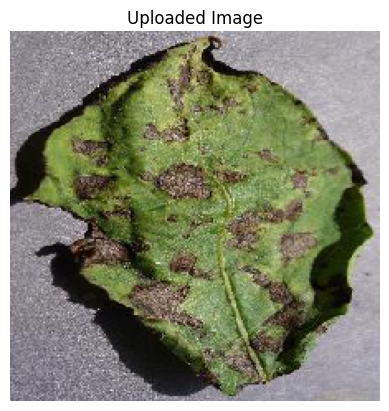

Predicted Disease : Potato___Early_blight
Confidence        : 100.00%


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

# Image path
img_path = "/content/test_potato_early_blight.jpg"

# Load image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict
predictions = model.predict(img_array)

predicted_index = np.argmax(predictions)
confidence = np.max(predictions) * 100

# Get class names
class_names = list(validation_generator.class_indices.keys())
predicted_class = class_names[predicted_index]

# Display image
plt.imshow(img)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

print(f"Predicted Disease : {predicted_class}")
print(f"Confidence        : {confidence:.2f}%")

In [32]:
import numpy as np
from sklearn.metrics import classification_report

# Reset generator
validation_generator.reset()

# Predict
predictions = model.predict(validation_generator, verbose=1)

# Predicted labels
y_pred = np.argmax(predictions, axis=1)

# True labels
y_true = validation_generator.classes

# Class names
class_names = list(validation_generator.class_indices.keys())

# Classification Report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

340/340 ━━━━━━━━━━━━━━━━━━━━ 160s 439ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.94      0.94      0.94       126
                                 Apple___Black_rot       0.96      0.97      0.96       124
                          Apple___Cedar_apple_rust       0.98      1.00      0.99        55
                                   Apple___healthy       0.96      0.98      0.97       329
                               Blueberry___healthy       1.00      0.99      0.99       300
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       210
                 Cherry_(including_sour)___healthy       0.99      0.98      0.98       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.81      0.86      0.84       102
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       238
               Corn_(maize)___Nort

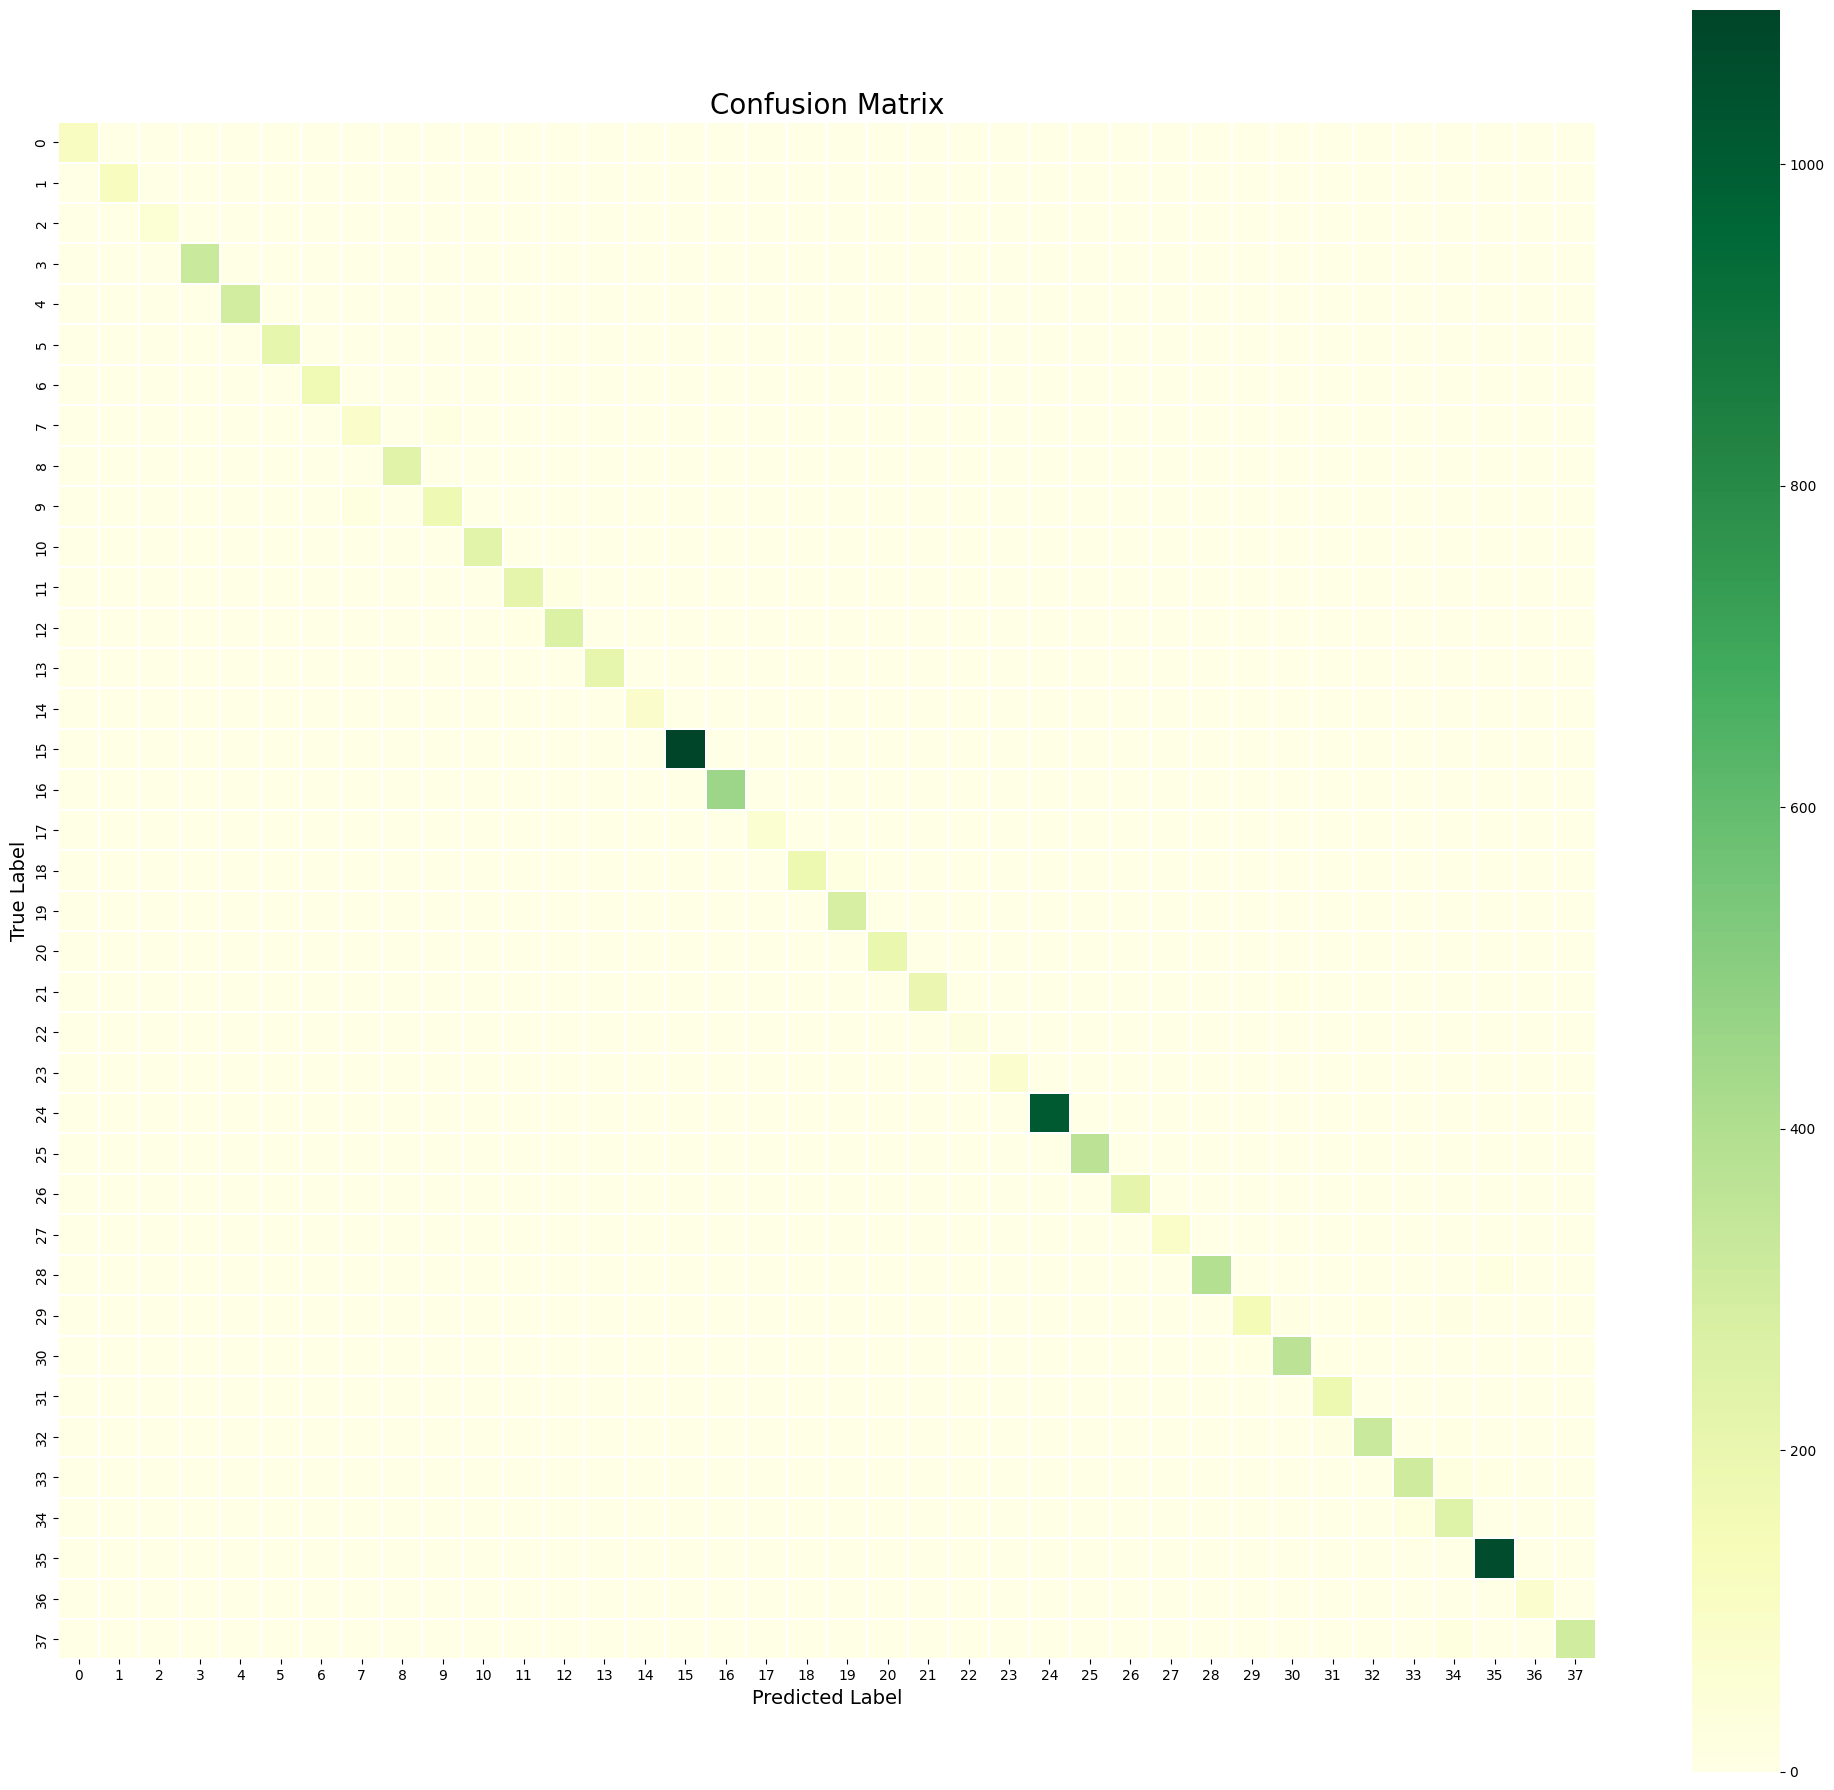

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20,18))

sns.heatmap(
    cm,
    cmap="YlGn",
    square=True,
    linewidths=0.2,
    cbar=True
)

plt.title("Confusion Matrix", fontsize=20)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)

plt.tight_layout()
plt.show()

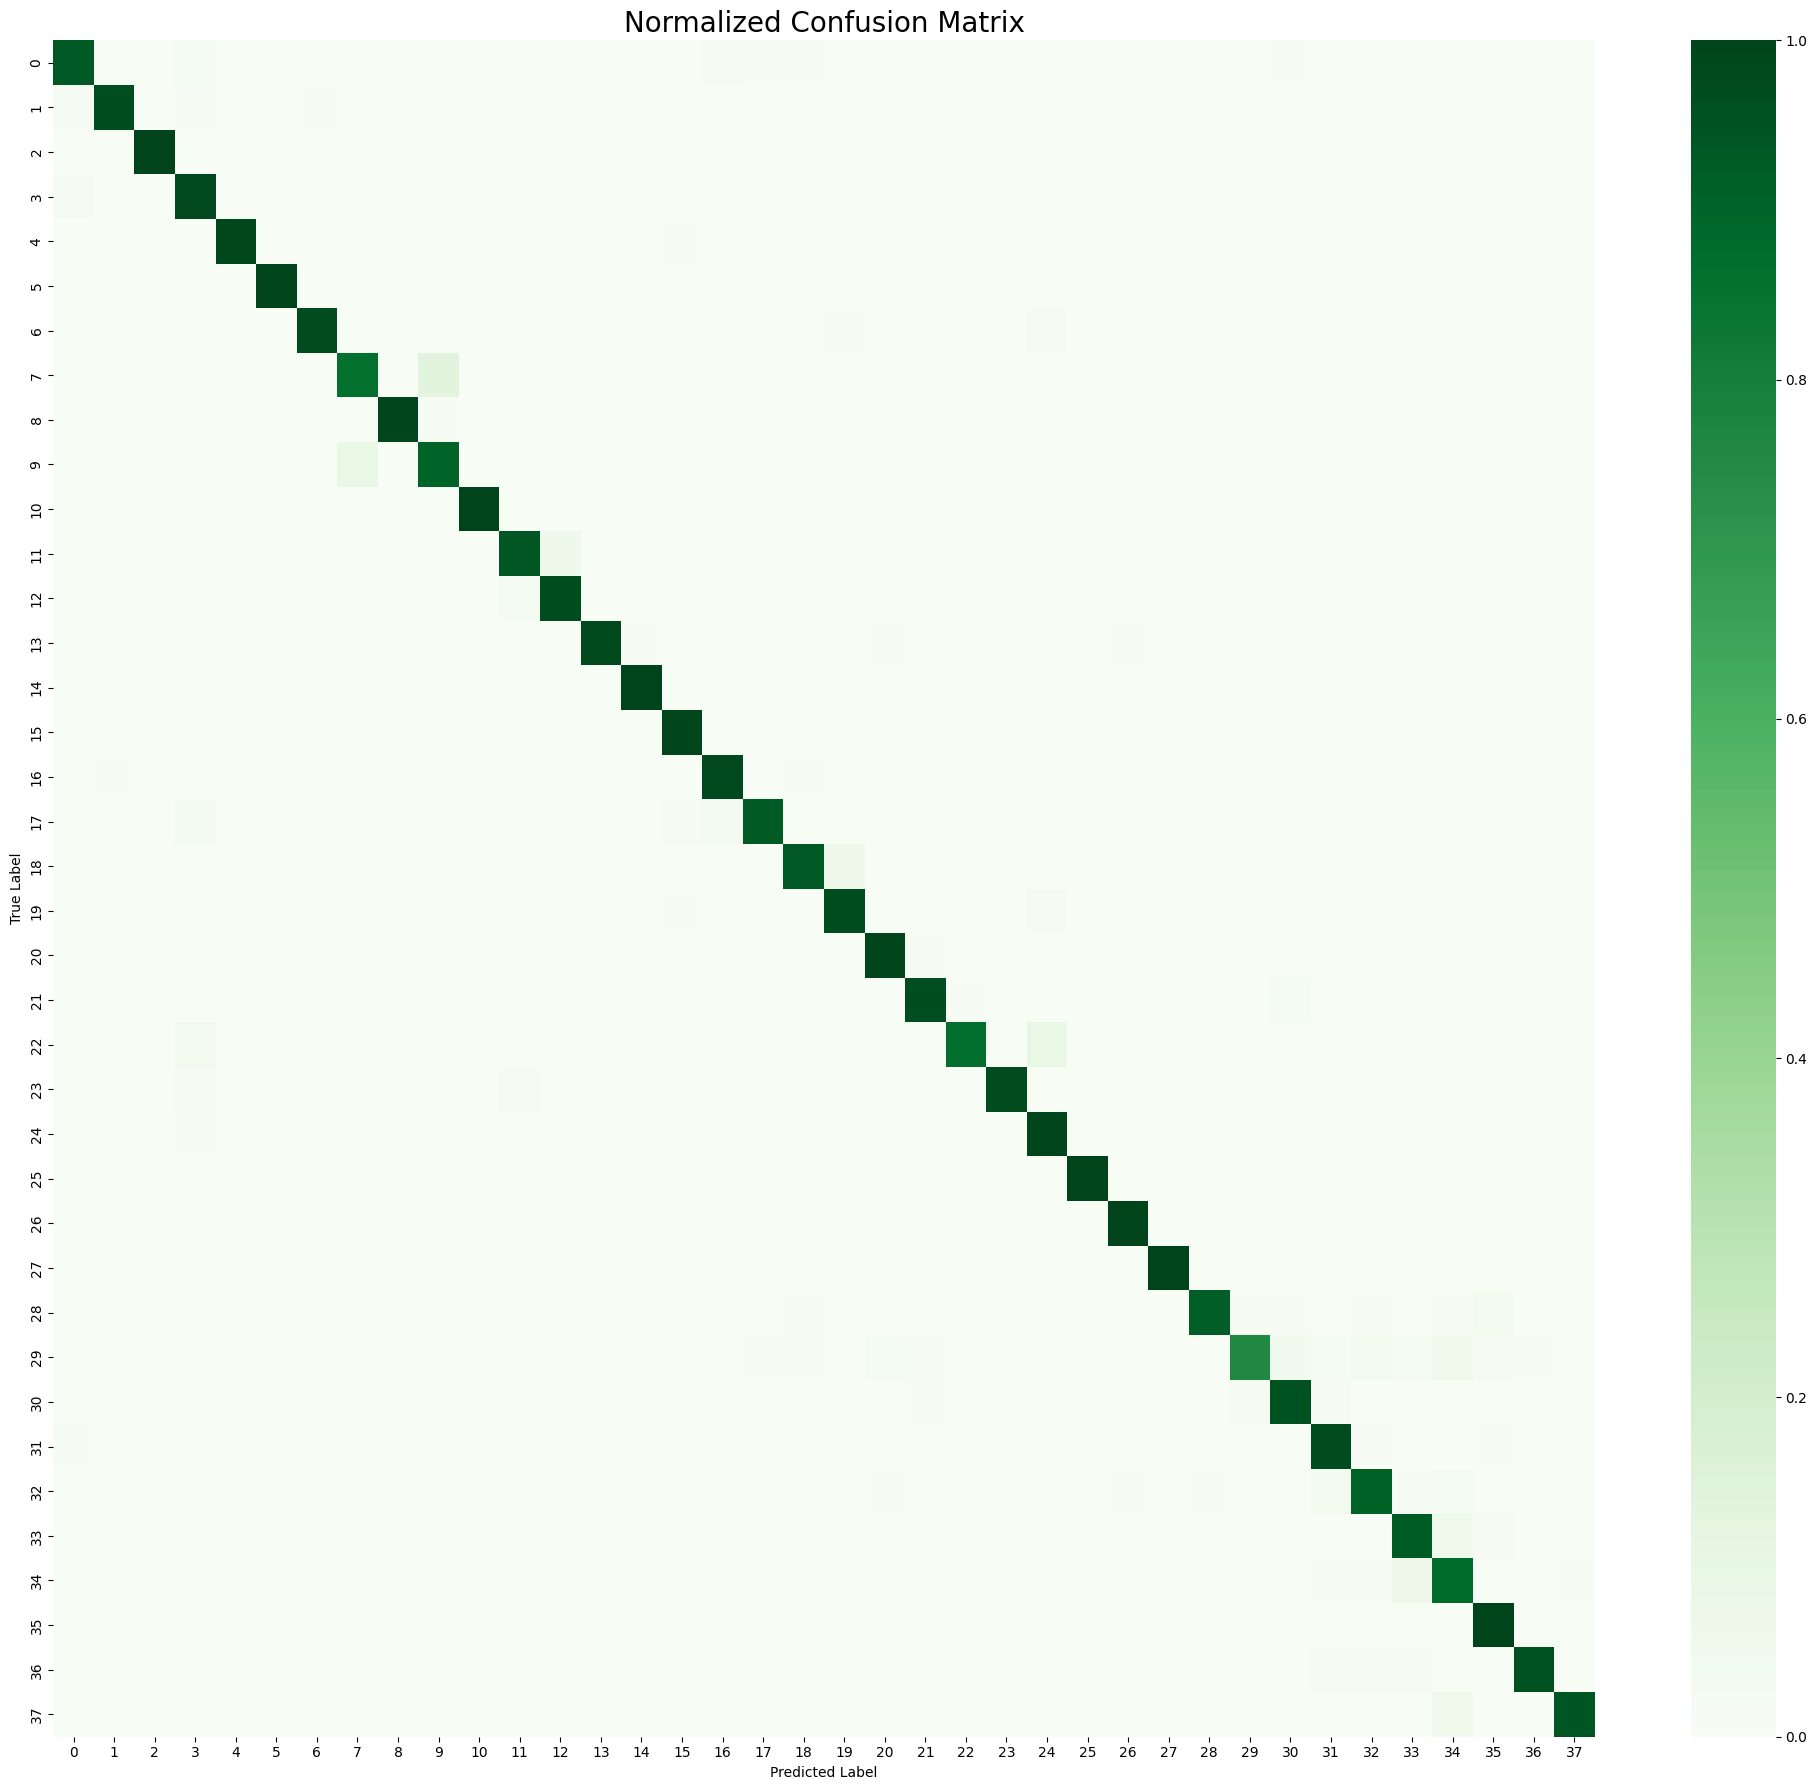

In [34]:
import numpy as np

cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(20,18))

sns.heatmap(
    cm_normalized,
    cmap="Greens",
    vmin=0,
    vmax=1
)

plt.title("Normalized Confusion Matrix", fontsize=20)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

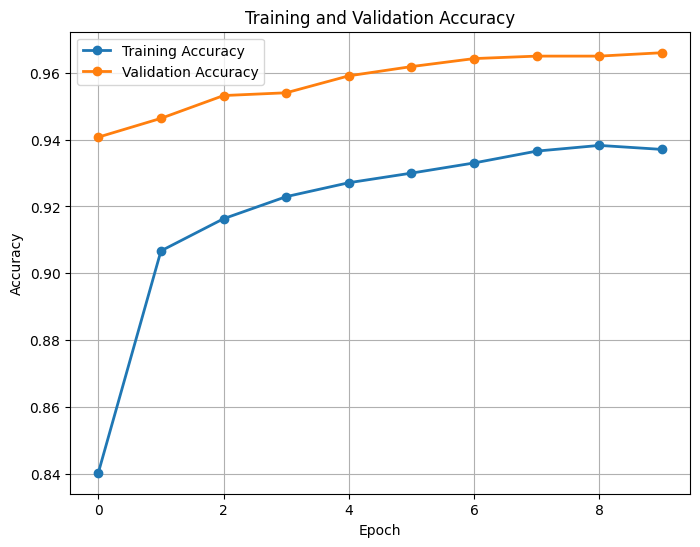

In [35]:
import pickle
import matplotlib.pyplot as plt

with open("/content/drive/MyDrive/PlantLeaf_EfficientNet/history_phase1.pkl","rb") as f:
    history = pickle.load(f)

plt.figure(figsize=(8,6))

plt.plot(history['accuracy'], marker='o', linewidth=2, label='Training Accuracy')
plt.plot(history['val_accuracy'], marker='o', linewidth=2, label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

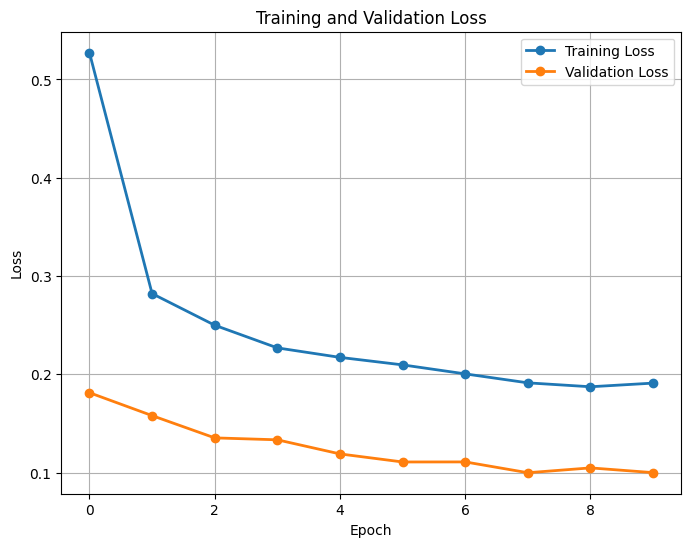

In [36]:
plt.figure(figsize=(8,6))

plt.plot(history['loss'], marker='o', linewidth=2, label='Training Loss')
plt.plot(history['val_loss'], marker='o', linewidth=2, label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()